## ELE632 Lab 5
#### Terry Chen 501236148

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, ifft, ifftshift
from scipy.signal import convolve, freqz
import soundfile as sf
import sounddevice as sd
from IPython.display import Audio

## Discrete Fourier Transform (DFT) Formulas

The **Discrete Fourier Transform** of a sequence $x_{n}$ is defined as:
$$X_{r}=\sum_{n=0}^{N_{0}-1}x_{n}e^{-jr\Omega_{0}n} \text{ , where } \Omega_{0}=\omega_{0}T=\frac{2\pi}{N_{0}}$$


The **Inverse Discrete Fourier Transform (IDFT)** is defined as:
$$x_{n}=\frac{1}{N_{0}}\sum_{r=0}^{N_{0}-1}X_{r}e^{jr\Omega_{0}n}$$

both $x_{n}$ and $X_{r}$ are periodic sequences with period $N_{0}$

#### Part A: Discrete Fourier Transform and Zero Padding
$$H = 4$$

$$I = 8$$


$$x_{1}[n]=e^{j2\pi n(10(H+1))/100}+e^{j2\pi n33/100}$$
$$x_{1}[n]=e^{j2\pi n(50)/100}+e^{j2\pi n33/100}$$


$$x_{2}[n]=2\cos(2\pi n(10(H+1))/100)+0.5\cos(2\pi n(10(I+1))/100)$$
$$x_{2}[n]=2\cos(2\pi n(50)/100)+0.5\cos(2\pi n(90)/100)$$

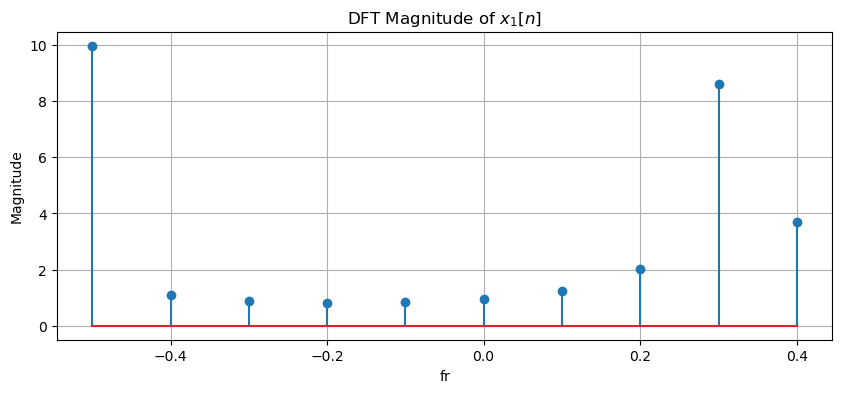

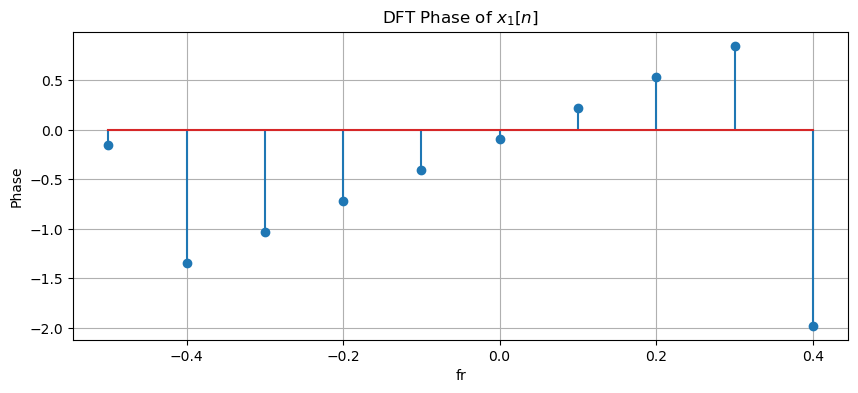

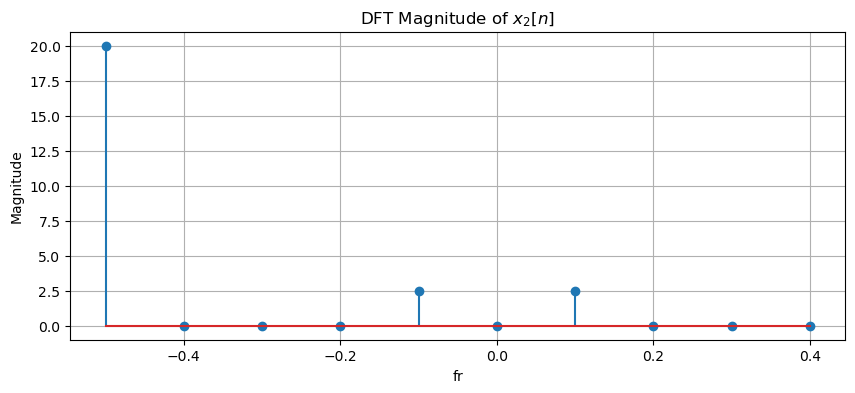

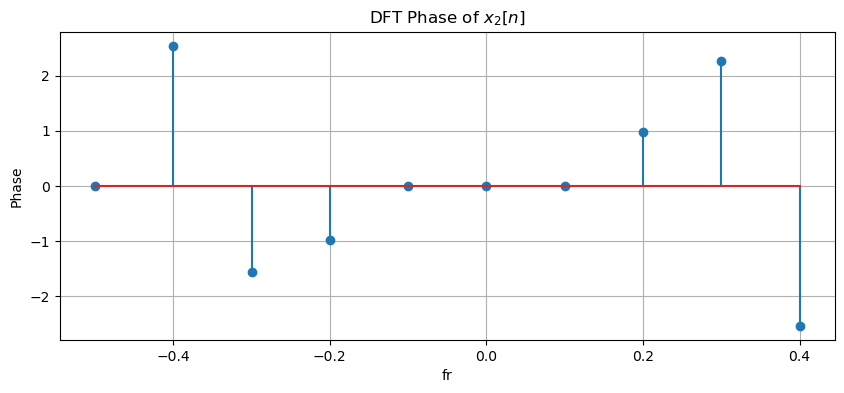

In [9]:
# A.1)
H = 4
I = 8

N = 10
n = np.arange(N)

x1 = np.exp(1j * 2 * np.pi * n * (10 * (H + 1)) / 100) + np.exp(1j * 2 * np.pi * n * 33 / 100)
x2 = 2 * np.cos(2 * np.pi * n * (10 * (H + 1)) / 100) + 0.5 * np.cos(2 * np.pi * n * (10 * (I + 1)) / 100)

X1 = np.fft.fft(x1)
X2 = np.fft.fft(x2)
X1_shift = np.fft.fftshift(X1)
X2_shift = np.fft.fftshift(X2)

# Frequency axis: fr = r/N
fr = np.fft.fftshift(np.fft.fftfreq(N))

# x1 Magnitude 
plt.figure(figsize=(10, 4))
plt.stem(fr, np.abs(X1_shift))
plt.title('DFT Magnitude of $x_1[n]$')
plt.xlabel('fr')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

# x1 Phase 
plt.figure(figsize=(10, 4))
plt.stem(fr, np.angle(X1_shift))
plt.title('DFT Phase of $x_1[n]$')
plt.xlabel('fr')
plt.ylabel('Phase')
plt.grid(True)
plt.show()

# x2 Magnitude 
plt.figure(figsize=(10, 4))
plt.stem(fr, np.abs(X2_shift))
plt.title('DFT Magnitude of $x_2[n]$')
plt.xlabel('fr')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

# x2 Phase 
plt.figure(figsize=(10, 4))
plt.stem(fr, np.angle(X2_shift))
plt.title('DFT Phase of $x_2[n]$')
plt.xlabel('fr')
plt.ylabel('Phase')
plt.grid(True)
plt.show()

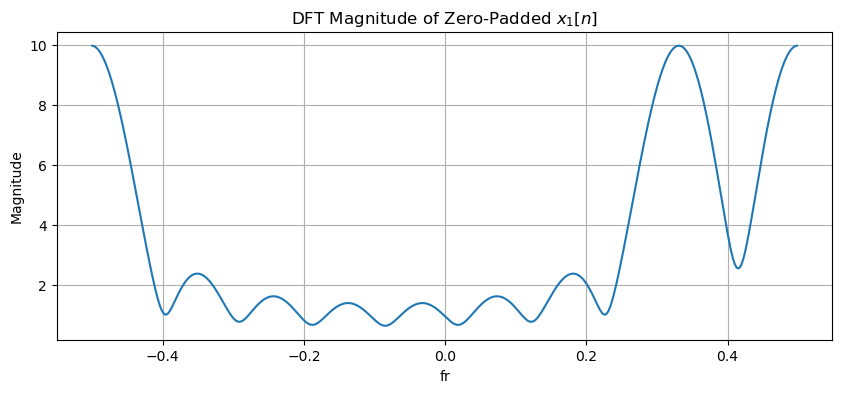

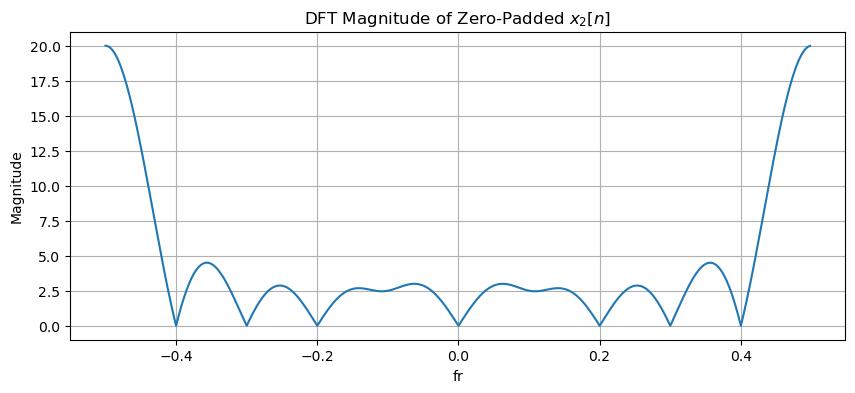

In [14]:
# A.2)
N_total = 500

# Zero-padding
x1_padded = np.pad(x1, (0, 490), 'constant')
x2_padded = np.pad(x2, (0, 490), 'constant')

X1_500 = np.fft.fftshift(np.fft.fft(x1_padded))
X2_500 = np.fft.fftshift(np.fft.fft(x2_padded))
fr_500 = np.fft.fftshift(np.fft.fftfreq(N_total))

# x1 Padded Magnitude 
plt.figure(figsize=(10, 4))
plt.plot(fr_500, np.abs(X1_500)) # Using plot instead of stem for high density
plt.title('DFT Magnitude of Zero-Padded $x_1[n]$')
plt.xlabel('fr')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

# x2 Padded Magnitude 
plt.figure(figsize=(10, 4))
plt.plot(fr_500, np.abs(X2_500))
plt.title('DFT Magnitude of Zero-Padded $x_2[n]$')
plt.xlabel('fr')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

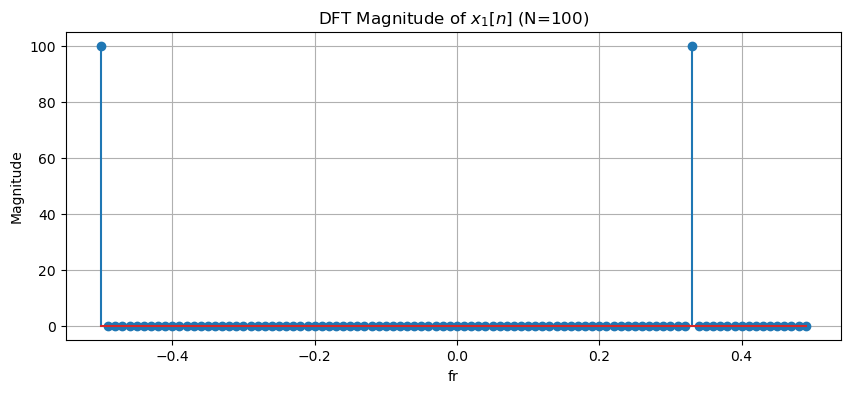

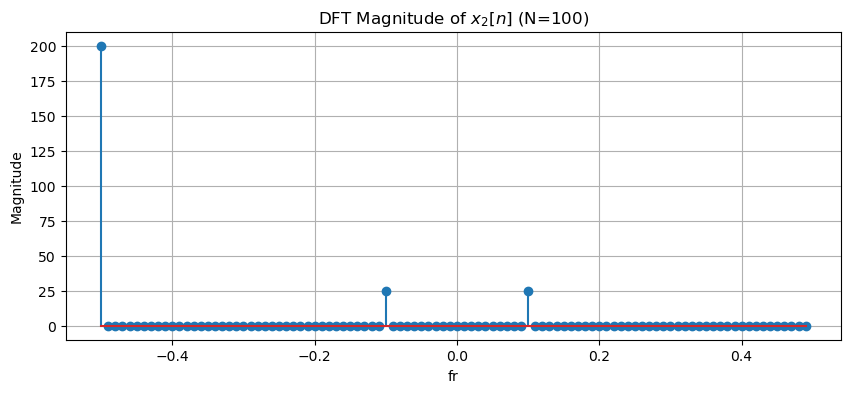

In [19]:
# A.3)
N_100 = 100
n_100 = np.arange(N_100)
x1_100 = np.exp(1j * 2 * np.pi * n_100 * (10 * (H + 1)) / 100) + np.exp(1j * 2 * np.pi * n_100 * 33 / 100)
x2_100 = 2 * np.cos(2 * np.pi * n_100 * (10 * (H + 1)) / 100) + 0.5 * np.cos(2 * np.pi * n_100 * (10 * (I + 1)) / 100)

X1_100 = np.fft.fftshift(np.fft.fft(x1_100))
X2_100 = np.fft.fftshift(np.fft.fft(x2_100))
fr_100 = np.fft.fftshift(np.fft.fftfreq(N_100))

# x1 Magnitude
plt.figure(figsize=(10, 4))
plt.stem(fr_100, np.abs(X1_100))
plt.title('DFT Magnitude of $x_1[n]$ (N=100)')
plt.xlabel('fr')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

# x2 Magnitude
plt.figure(figsize=(10, 4))
plt.stem(fr_100, np.abs(X2_100))
plt.title('DFT Magnitude of $x_2[n]$ (N=100)')
plt.xlabel('fr')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

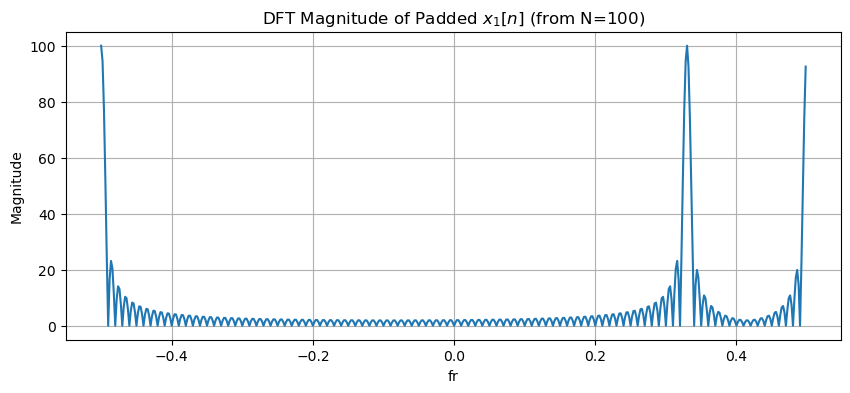

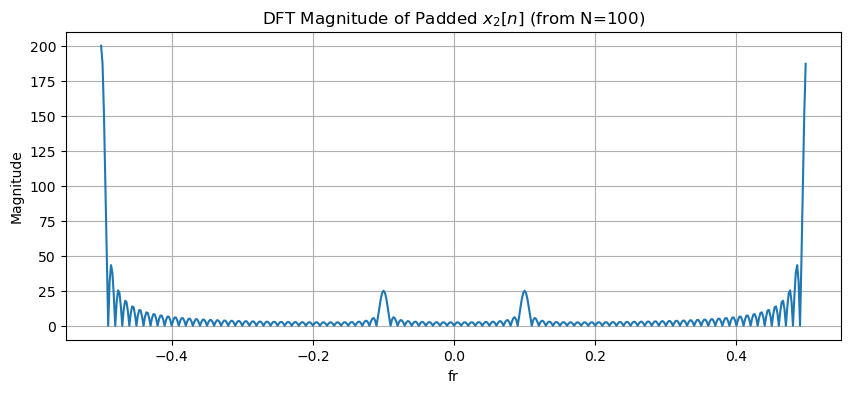

In [20]:
# A.4)
N_100 = 100
N_total = 500
n = np.arange(N_100)

# Zero-pad with 400 zeros
x1_padded_500 = np.pad(x1_100, (0, 400), 'constant')
x2_padded_500 = np.pad(x2_100, (0, 400), 'constant')

X1_500_shift = np.fft.fftshift(np.fft.fft(x1_padded_500))
X2_500_shift = np.fft.fftshift(np.fft.fft(x2_padded_500))
fr_500 = np.fft.fftshift(np.fft.fftfreq(N_total))

# x1 Magnitude
plt.figure(figsize=(10, 4))
plt.plot(fr_500, np.abs(X1_500_shift))
plt.title('DFT Magnitude of Padded $x_1[n]$ (from N=100)')
plt.xlabel('fr')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

# x2 Magnitude
plt.figure(figsize=(10, 4))
plt.plot(fr_500, np.abs(X2_500_shift))
plt.title('DFT Magnitude of Padded $x_2[n]$ (from N=100)')
plt.xlabel('fr')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

#### Part B: Sampling

Audio file: ./audio.wav

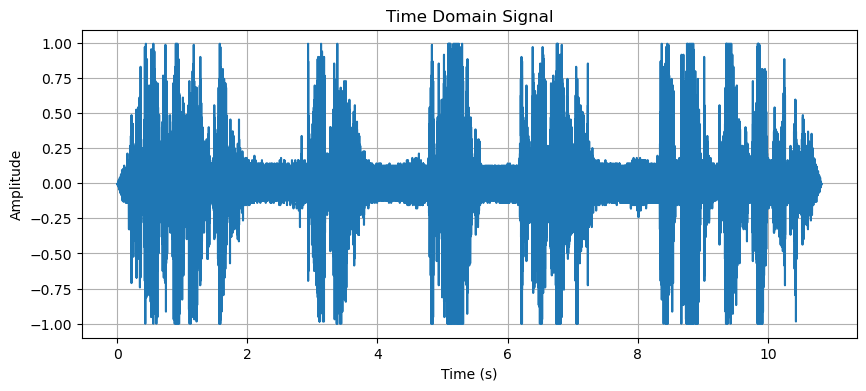

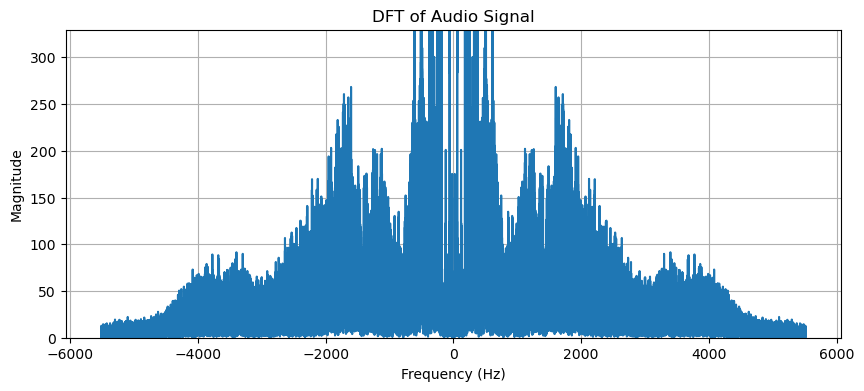

In [34]:
filename = 'audio.wav'
y, fs = sf.read(filename)

# number of samples, sampling interval, signal duration
N0 = len(y)
T = 1 / fs
T0 = N0 * T

# B.2)
time = np.linspace(0, T0, N0)
plt.figure(figsize=(10, 4))
plt.plot(time, y)
plt.title('Time Domain Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# B.3)
y_clean = y - np.mean(y) # fix dc offset
Y = np.fft.fft(y_clean)
Y_mag = np.fft.fftshift(np.abs(Y))
freq = np.fft.fftshift(np.fft.fftfreq(N0, d=T))

plt.figure(figsize=(10, 4))
plt.plot(freq, Y_mag)
plt.ylim(0, np.percentile(Y_mag, 99.9))
plt.title('DFT of Audio Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

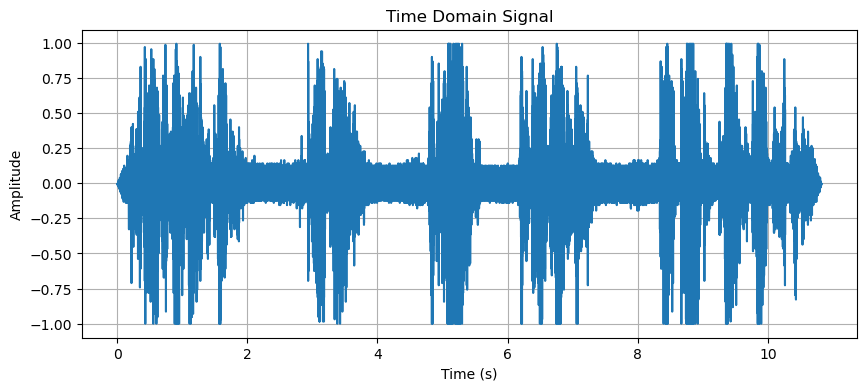

In [35]:
# B.4)
M = 2
y1 = y[::M]  # every 2nd sample
N1 = len(y1)

fs1 = fs / M  
T1 = 1 / fs1
T0_1 = N1 * T1

# B.5)
time = np.linspace(0, T0_1, N1)
plt.figure(figsize=(10, 4))
plt.plot(time, y1)
plt.title('Subsampling Time Domain Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

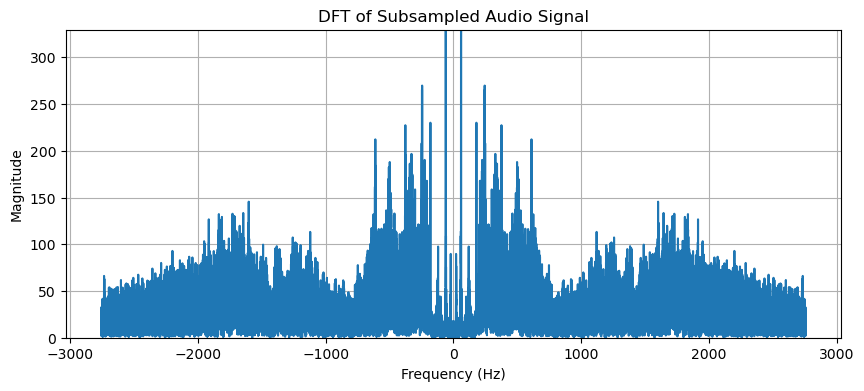

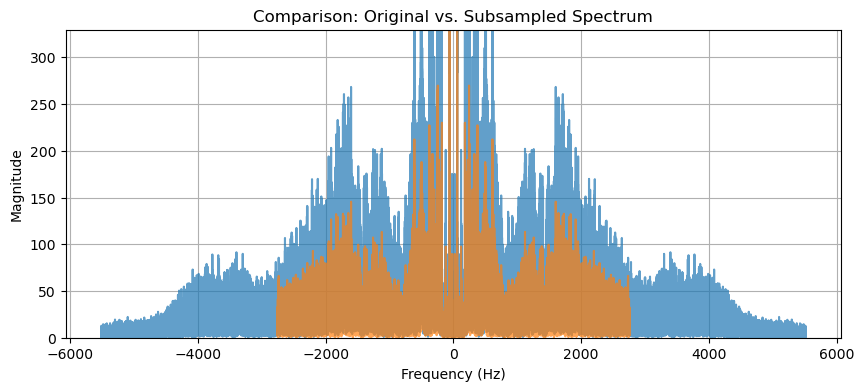

In [41]:
# B.6)
y1_clean = y1 - np.mean(y1)
Y1 = np.fft.fft(y1_clean)
Y1_mag = np.fft.fftshift(np.abs(Y1))
freq1 = np.fft.fftshift(np.fft.fftfreq(N1, d=T1))

# Full Spectrum of y1
plt.figure(figsize=(10, 4))
plt.plot(freq1, Y1_mag)
plt.ylim(0, np.percentile(Y_mag, 99.9))
plt.title('DFT of Subsampled Audio Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

# Zoomed version
plt.figure(figsize=(10, 4))
plt.plot(freq, Y_mag, alpha=0.7)
plt.plot(freq1, Y1_mag, alpha=0.7)
plt.ylim(0, np.percentile(Y_mag, 99.9))
plt.title('Comparison: Original vs. Subsampled Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

In [43]:
# original audio
Audio(y, rate=fs)

In [47]:
# subsampled audio (M = 2)
Audio(y1, rate=fs1)

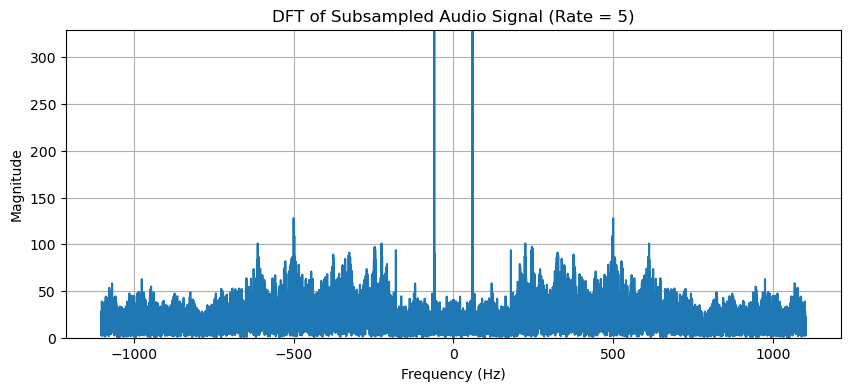

In [49]:
# B.8)
M2 = 5
y2 = y[::M2]
N2 = len(y2)
fs2 = fs / M2

y2_clean = y2 - np.mean(y2)
Y2 = np.fft.fft(y2_clean)
Y2_mag = np.fft.fftshift(np.abs(Y2))
freq2 = np.fft.fftshift(np.fft.fftfreq(N2, d=1/fs2))

plt.figure(figsize=(10, 4))
plt.plot(freq2, Y2_mag)
plt.ylim(0, np.percentile(Y_mag, 99.9))
plt.title('DFT of Subsampled Audio Signal (Rate = 5)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

In [60]:
# subsampled audio (M = 5)
Audio(y2, rate=fs2) # broken from severe aliasing

#### Part C: Filter design
An audio equalizer to adjust the frequency components of the audio signal

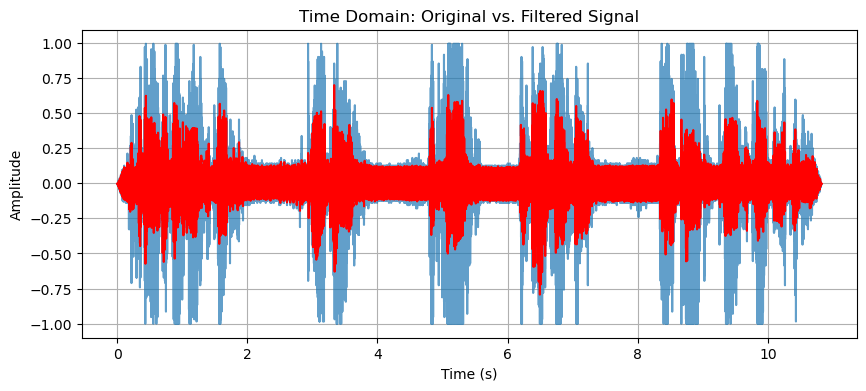

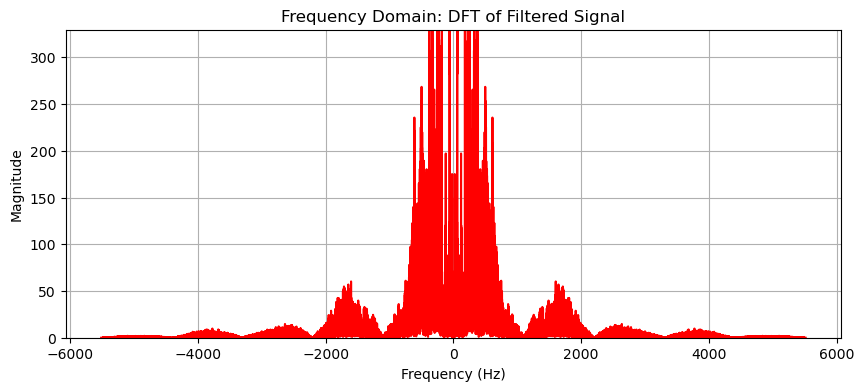

In [93]:
L = 10 
h = np.ones(L) / L
time = np.linspace(0, T0, N0)

y_filt = np.convolve(y, h, mode='same')

# Time Domain Comparison
plt.figure(figsize=(10, 4))
plt.plot(time, y, alpha=0.7)
plt.plot(time, y_filt, color='red')
plt.title('Time Domain: Original vs. Filtered Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# Frequency Domain
y_filt_clean = y_filt - np.mean(y_filt)
Y_filt_DFT = np.fft.fftshift(np.abs(np.fft.fft(y_filt_clean)))
freq_filt = np.fft.fftshift(np.fft.fftfreq(len(y_filt), d=T))

plt.figure(figsize=(10, 4))
plt.plot(freq_filt, Y_filt_DFT, color='red')
plt.ylim(0, np.percentile(Y_mag, 99.9))
plt.title('Frequency Domain: DFT of Filtered Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

In [70]:
# C.2) filtered
Audio(y_filt, rate=fs)

<Figure size 1000x400 with 0 Axes>

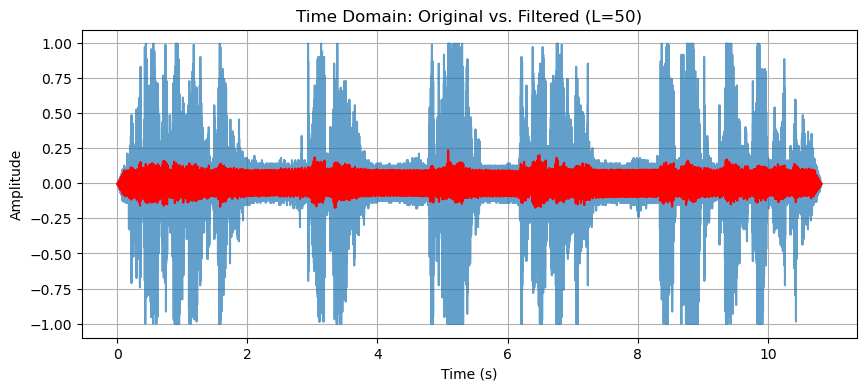

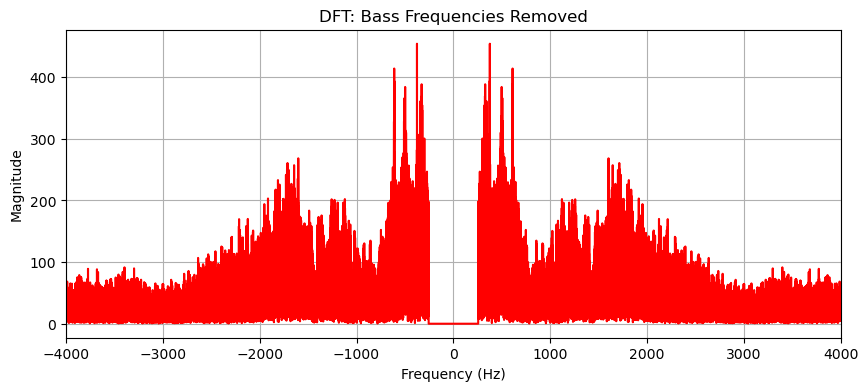

In [87]:
# C.3)
N = len(y)
Y = np.fft.fft(y)
freqs = np.fft.fftfreq(N, d=1/fs)

mask = np.ones(N)
mask[np.abs(freqs) <= 256] = 0 # < 256 Hz
Y_filtered = Y * mask
y_filtered_time = np.fft.ifft(Y_filtered).real

plt.figure(figsize=(10, 4))
shifted_f = np.fft.fftshift(freqs)
shifted_m = np.fft.fftshift(np.abs(Y_filtered))

plt.figure(figsize=(10, 4))
plt.plot(time, y, alpha=0.7)
plt.plot(time, y_filt_long, color='red')
plt.title(f'Time Domain: Original vs. Filtered (L={L_new})')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(shifted_f, shifted_m, color='red')
plt.title('DFT: Bass Frequencies Removed')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(-4000, 4000)
plt.grid(True)
plt.show()

In [78]:
# bass removed
Audio(y_filtered_time, rate=fs)

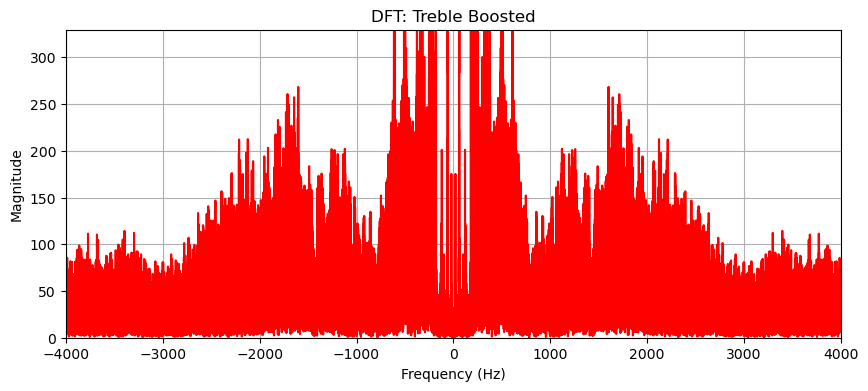

In [91]:
# C.4)
N = len(y)
Y = np.fft.fft(y)
freqs = np.fft.fftfreq(N, d=1/fs)

# If frequency is in the treble range (2048-16384Hz), gain = 1.25
treble_mask = (np.abs(freqs) >= 2048) & (np.abs(freqs) <= 16384)
rect_filter = np.where(treble_mask, 1.25, 1.0)

Y_boosted = Y * rect_filter
y_boosted_time = np.fft.ifft(Y_boosted).real

shifted_f = np.fft.fftshift(freqs)
shifted_orig = np.fft.fftshift(np.abs(Y))
shifted_boost = np.fft.fftshift(np.abs(Y_boosted))

plt.figure(figsize=(10, 4))
plt.plot(shifted_f, shifted_boost, color='red')
plt.ylim(0, np.percentile(Y_mag, 99.9))
plt.title('DFT: Treble Boosted')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(-4000, 4000) 
plt.grid(True)
plt.show()

In [89]:
# treble boosted
Audio(y_boosted_time, rate=fs)